## Step 1: Environment Setup and Image Loading
### Tasks 1 & 2: Load Image and Convert to Grayscale
In this step, we import the required libraries (`cv2`, `numpy`, `matplotlib.pyplot`) and use Google Colab's file upload interface to load the surface defect image into our runtime[cite: 1, 2]. We read the image using OpenCV, convert it from BGR to RGB for correct color display, and convert it to grayscale to simplify pixel intensity values from 3 color channels down to a single channel (0–255) for all subsequent processing operations[cite: 1, 2].

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload downloaded image from local PC
uploaded = files.upload()
filename = next(iter(uploaded))

# Task 1: Read and store original image
img_bgr = cv2.imread(filename)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Task 2: Convert to grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

Saving machinery-cracking-600x300px.jpg to machinery-cracking-600x300px.jpg


## Part A - Tasks 1 & 2: Display Original vs. Grayscale Images
We visualize the uploaded RGB image alongside its single-channel grayscale representation using Matplotlib[cite: 1, 2]. Grayscale conversion eliminates chromatic variance while preserving defect boundaries, surface textures, and crack features[cite: 1, 2].

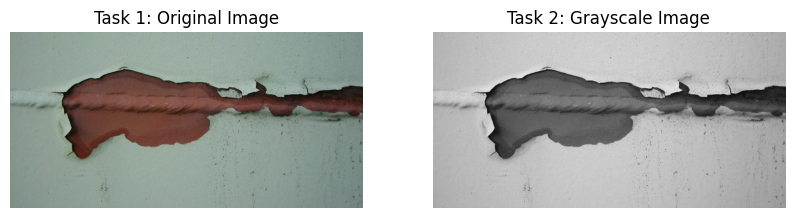

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("Task 1: Original Image")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Task 2: Grayscale Image")
axes[1].axis("off")
plt.show()

## Part A - Task 3: Grayscale Histogram Analysis
We plot the intensity histogram across 256 bins (range 0–255) to analyze the dynamic tone distribution of the surface[cite: 1, 2]. Peaks indicate dominant material tones, while lower or isolated bins indicate surface irregularities, shadows, scratches, and pitting defects[cite: 1, 2].

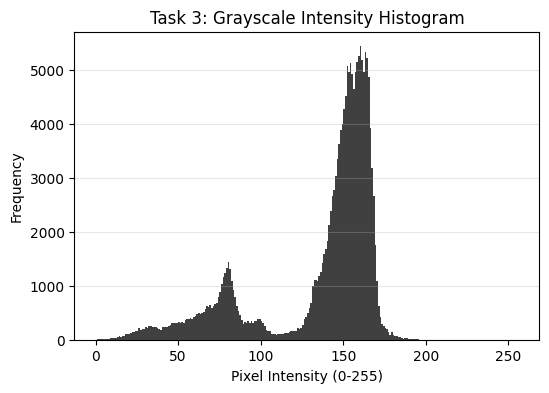

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
plt.title("Task 3: Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

## Part A - Task 4: Brightness and Contrast Scaling
We apply a linear transformation $g(x) = \alpha \cdot f(x) + \beta$ using `cv2.convertScaleAbs`[cite: 1, 2]. The gain parameter $\alpha > 1$ amplifies contrast by widening intensity differences between dark crack lines and lighter surfaces, while $\beta$ shifts baseline brightness[cite: 1, 2].

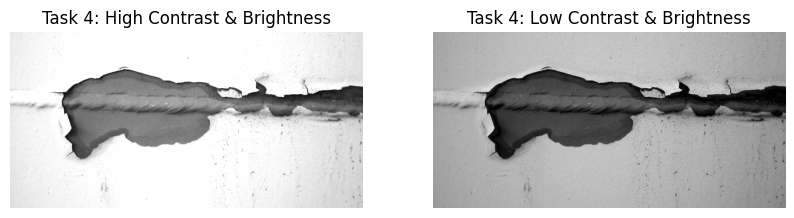

In [4]:
high_contrast = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=20)
low_contrast = cv2.convertScaleAbs(img_gray, alpha=0.6, beta=-20)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(high_contrast, cmap='gray')
axes[0].set_title("Task 4: High Contrast & Brightness")
axes[0].axis("off")

axes[1].imshow(low_contrast, cmap='gray')
axes[1].set_title("Task 4: Low Contrast & Brightness")
axes[1].axis("off")
plt.show()

## Part A - Task 5: Introduce Synthetic Sensor / Camera Noise
Inspection cameras often introduce sensor noise or transmission artifacts. We simulate salt-and-pepper (impulse) noise by setting random pixel coordinates across the image matrix to maximum intensity (255) to test subsequent noise-filtering robustness[cite: 1, 2].

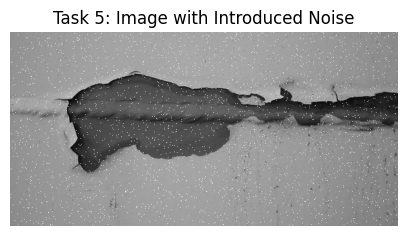

In [5]:
noisy_img = img_gray.copy()
num_noise_pixels = 2500
coords = [np.random.randint(0, i - 1, num_noise_pixels) for i in img_gray.shape]
noisy_img[coords[0], coords[1]] = 255

plt.figure(figsize=(5, 5))
plt.imshow(noisy_img, cmap='gray')
plt.title("Task 5: Image with Introduced Noise")
plt.axis("off")
plt.show()

## Part A - Tasks 6 & 7: Noise Removal via Gaussian and Median Filtering
We evaluate two spatial filters for defect preservation[cite: 1, 2]:
- **Gaussian Filter (Task 6):** Convolves the image with a Gaussian kernel, averaging neighboring pixels to smooth noise, but slightly blurs fine defect edges[cite: 1, 2].
- **Median Filter (Task 7):** A non-linear filter that replaces each pixel with the median value of its neighborhood, removing salt-and-pepper noise spikes while keeping critical defect boundaries sharp[cite: 1, 2].

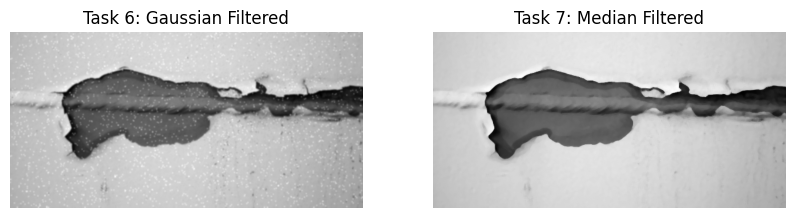

In [6]:
gaussian_filtered = cv2.GaussianBlur(noisy_img, (5, 5), sigmaX=0)
median_filtered = cv2.medianBlur(noisy_img, ksize=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gaussian_filtered, cmap='gray')
axes[0].set_title("Task 6: Gaussian Filtered")
axes[0].axis("off")

axes[1].imshow(median_filtered, cmap='gray')
axes[1].set_title("Task 7: Median Filtered")
axes[1].axis("off")
plt.show()

## Part A - Task 8: Histogram Equalization
We apply `cv2.equalizeHist` to stretch the cumulative distribution function (CDF) of pixel intensities across the full 0–255 spectrum[cite: 1, 2]. This reveals subtle scratch and crack details that were previously hidden in low-contrast, uniformly illuminated areas[cite: 1, 2].

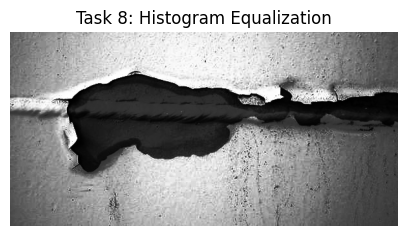

In [7]:
equalized_img = cv2.equalizeHist(img_gray)

plt.figure(figsize=(5, 5))
plt.imshow(equalized_img, cmap='gray')
plt.title("Task 8: Histogram Equalization")
plt.axis("off")
plt.show()

## Part A - Tasks 9 & 10: Comparison of Preprocessing Methods and Recommendation
We consolidate all enhancement outputs from Tasks 1 through 8 into a unified 2x4 comparison grid[cite: 1, 2].

### Task 10 Recommendation:
- **Median Filtering** is the most suitable method for noise removal because it effectively eliminates impulse noise without blurring the sharp boundaries of cracks and scratches[cite: 1, 2].
- **Histogram Equalization** is recommended when raw input images suffer from poor dynamic range and low surface contrast[cite: 1, 2].

/tmp/ipykernel_3021/1896438213.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.hist(img_gray.ravel(), 256, [0, 256], color='black')


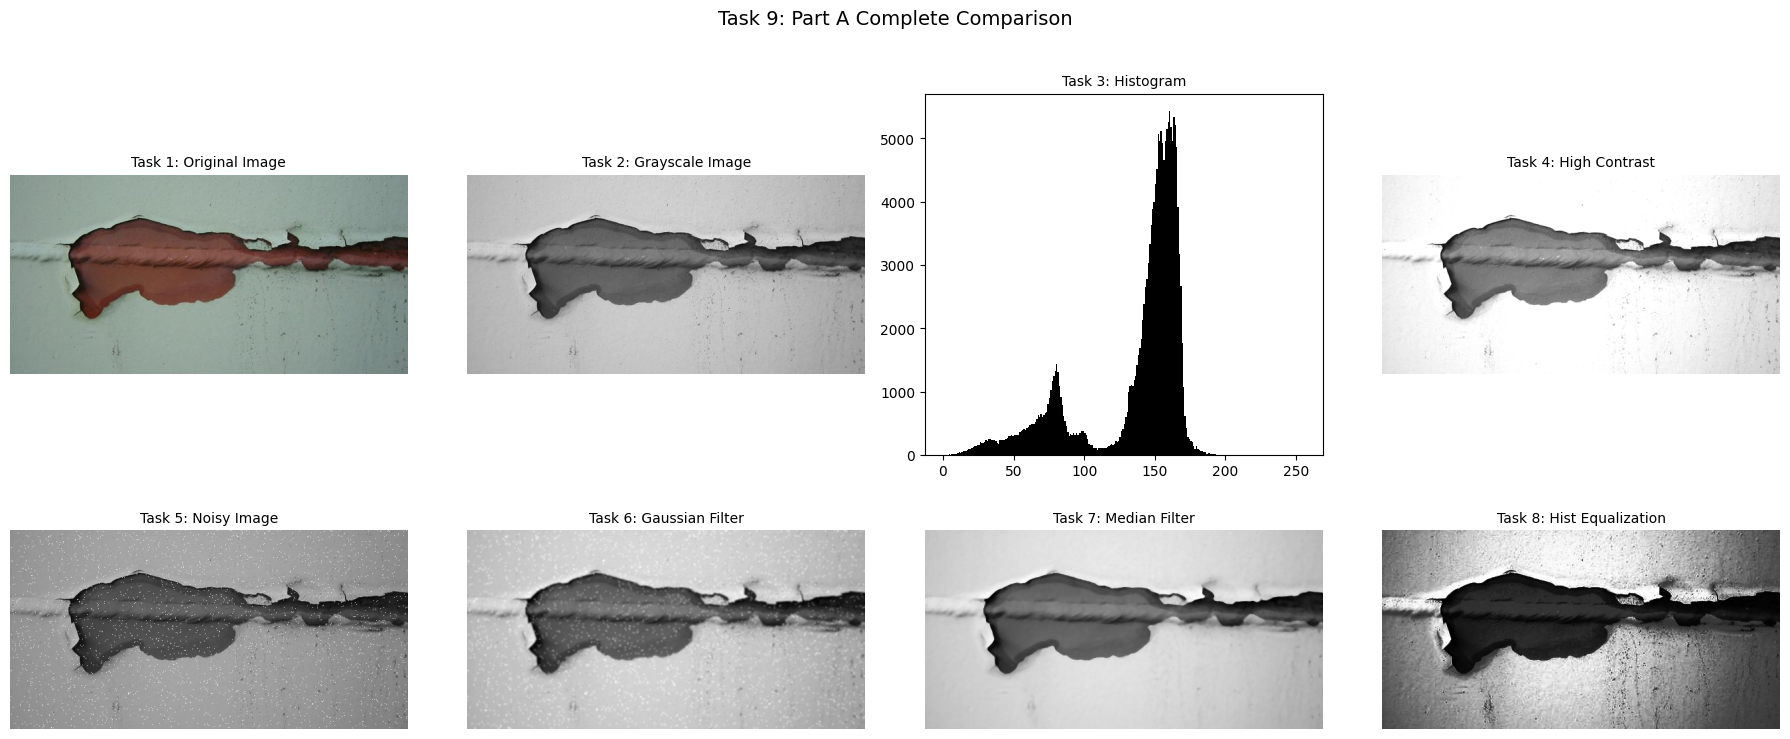

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

part_a_outputs = [
    (img_rgb, "Task 1: Original Image", True),
    (img_gray, "Task 2: Grayscale Image", False),
    (None, "Task 3: Histogram", "hist"),
    (high_contrast, "Task 4: High Contrast", False),
    (noisy_img, "Task 5: Noisy Image", False),
    (gaussian_filtered, "Task 6: Gaussian Filter", False),
    (median_filtered, "Task 7: Median Filter", False),
    (equalized_img, "Task 8: Hist Equalization", False)
]

for ax, (im, title, is_special) in zip(axes.flat, part_a_outputs):
    if is_special == "hist":
        ax.hist(img_gray.ravel(), 256, [0, 256], color='black')
        ax.set_title(title, fontsize=10)
    elif is_special:
        ax.imshow(im)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    else:
        ax.imshow(im, cmap='gray')
        ax.set_title(title, fontsize=10)
        ax.axis("off")

plt.suptitle("Task 9: Part A Complete Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Part B - Task 3: Binary Segmentation via Multiple Threshold Values
We apply simple global binary inverse thresholding (`cv2.THRESH_BINARY_INV`) using three distinct threshold cutoffs ($T_1=70$, $T_2=120$, $T_3=170$)[cite: 1, 2]. Pixels darker than $T$ turn white (representing defect regions), while the background turns black[cite: 1, 2]. This illustrates how manual cutoff choices lead to under-segmentation or over-segmentation[cite: 1, 2].

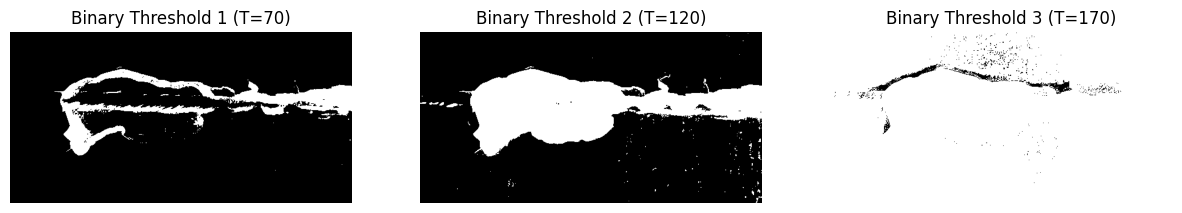

In [9]:
_, thresh_1 = cv2.threshold(img_gray, 70, 255, cv2.THRESH_BINARY_INV)
_, thresh_2 = cv2.threshold(img_gray, 120, 255, cv2.THRESH_BINARY_INV)
_, thresh_3 = cv2.threshold(img_gray, 170, 255, cv2.THRESH_BINARY_INV)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(thresh_1, cmap='gray'); axes[0].set_title("Binary Threshold 1 (T=70)"); axes[0].axis("off")
axes[1].imshow(thresh_2, cmap='gray'); axes[1].set_title("Binary Threshold 2 (T=120)"); axes[1].axis("off")
axes[2].imshow(thresh_3, cmap='gray'); axes[2].set_title("Binary Threshold 3 (T=170)"); axes[2].axis("off")
plt.show()

## Part B - Task 4: Otsu's Automatic Thresholding
Otsu's thresholding automatically computes the optimal binarization cutoff value by minimizing intra-class pixel variance (or maximizing inter-class variance) between foreground defect pixels and background metal pixels, avoiding subjective manual tuning[cite: 1, 2].

Optimal Otsu Threshold computed: 111.0


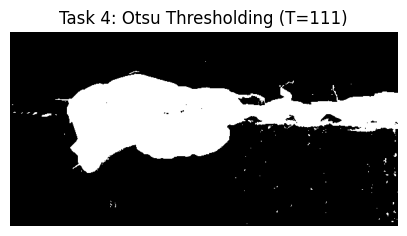

In [10]:
otsu_val, otsu_output = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Optimal Otsu Threshold computed: {otsu_val}")

plt.figure(figsize=(5, 5))
plt.imshow(otsu_output, cmap='gray')
plt.title(f"Task 4: Otsu Thresholding (T={int(otsu_val)})")
plt.axis("off")
plt.show()

## Part B - Task 5: Canny Edge Detection
Canny edge detection identifies defect boundaries through gradient computation, non-maximum suppression, and hysteresis thresholding[cite: 1, 2]. We evaluate two parameter pairs:
- **Parameter Set 1 (50, 150):** Lower hysteresis limits, capturing subtle and thin crack lines[cite: 1, 2].
- **Parameter Set 2 (120, 240):** Higher limits, filtering surface micro-texture noise but risking edge discontinuity[cite: 1, 2].

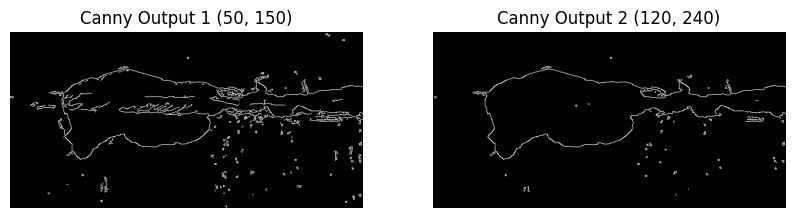

In [11]:
canny_output_1 = cv2.Canny(img_gray, threshold1=50, threshold2=150)
canny_output_2 = cv2.Canny(img_gray, threshold1=120, threshold2=240)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(canny_output_1, cmap='gray')
axes[0].set_title("Canny Output 1 (50, 150)")
axes[0].axis("off")

axes[1].imshow(canny_output_2, cmap='gray')
axes[1].set_title("Canny Output 2 (120, 240)")
axes[1].axis("off")
plt.show()

## Part B - Tasks 6 & 7: Segmentation Comparison and Final Justification
We compare the 3 manual thresholds, Otsu's mask, and the 2 Canny edge detector outputs in a 2x3 grid[cite: 1, 2].

### Task 7 Recommendation and Justification:
- **Otsu’s Thresholding** is recommended for complete region segmentation as it computes the optimal threshold mathematically from the histogram without user bias[cite: 1, 2].
- **Canny Edge Detection (50, 150)** is recommended for tracing thin scratch paths and crack contours without fragmenting the continuous defect edges[cite: 1, 2].

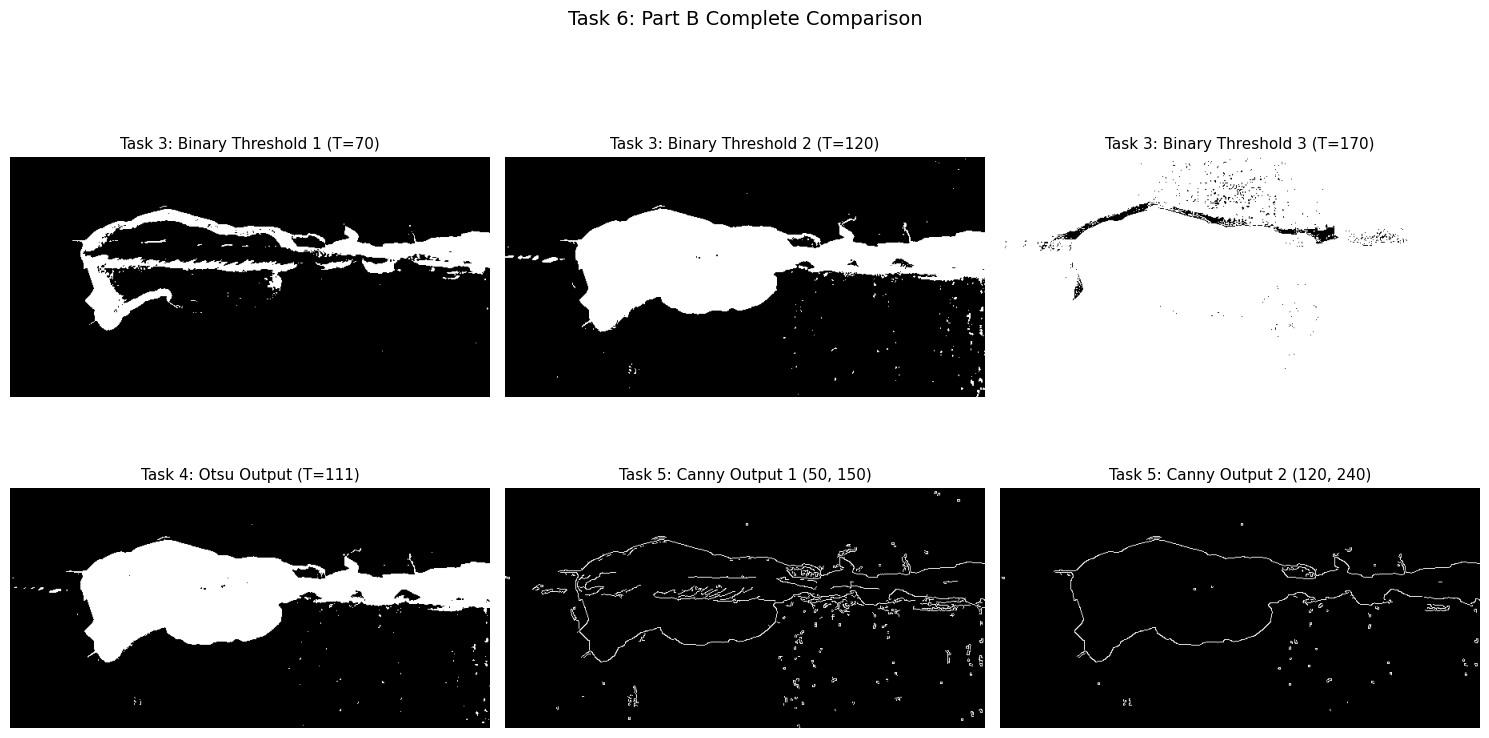

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

part_b_outputs = [
    (thresh_1, "Task 3: Binary Threshold 1 (T=70)"),
    (thresh_2, "Task 3: Binary Threshold 2 (T=120)"),
    (thresh_3, "Task 3: Binary Threshold 3 (T=170)"),
    (otsu_output, f"Task 4: Otsu Output (T={int(otsu_val)})"),
    (canny_output_1, "Task 5: Canny Output 1 (50, 150)"),
    (canny_output_2, "Task 5: Canny Output 2 (120, 240)")
]

for ax, (im, title) in zip(axes.flat, part_b_outputs):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Task 6: Part B Complete Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Final Expected Output Summary Matrix
The consolidated output matrix displays the exact comparison required by the lab manual guidelines[cite: 1, 2].

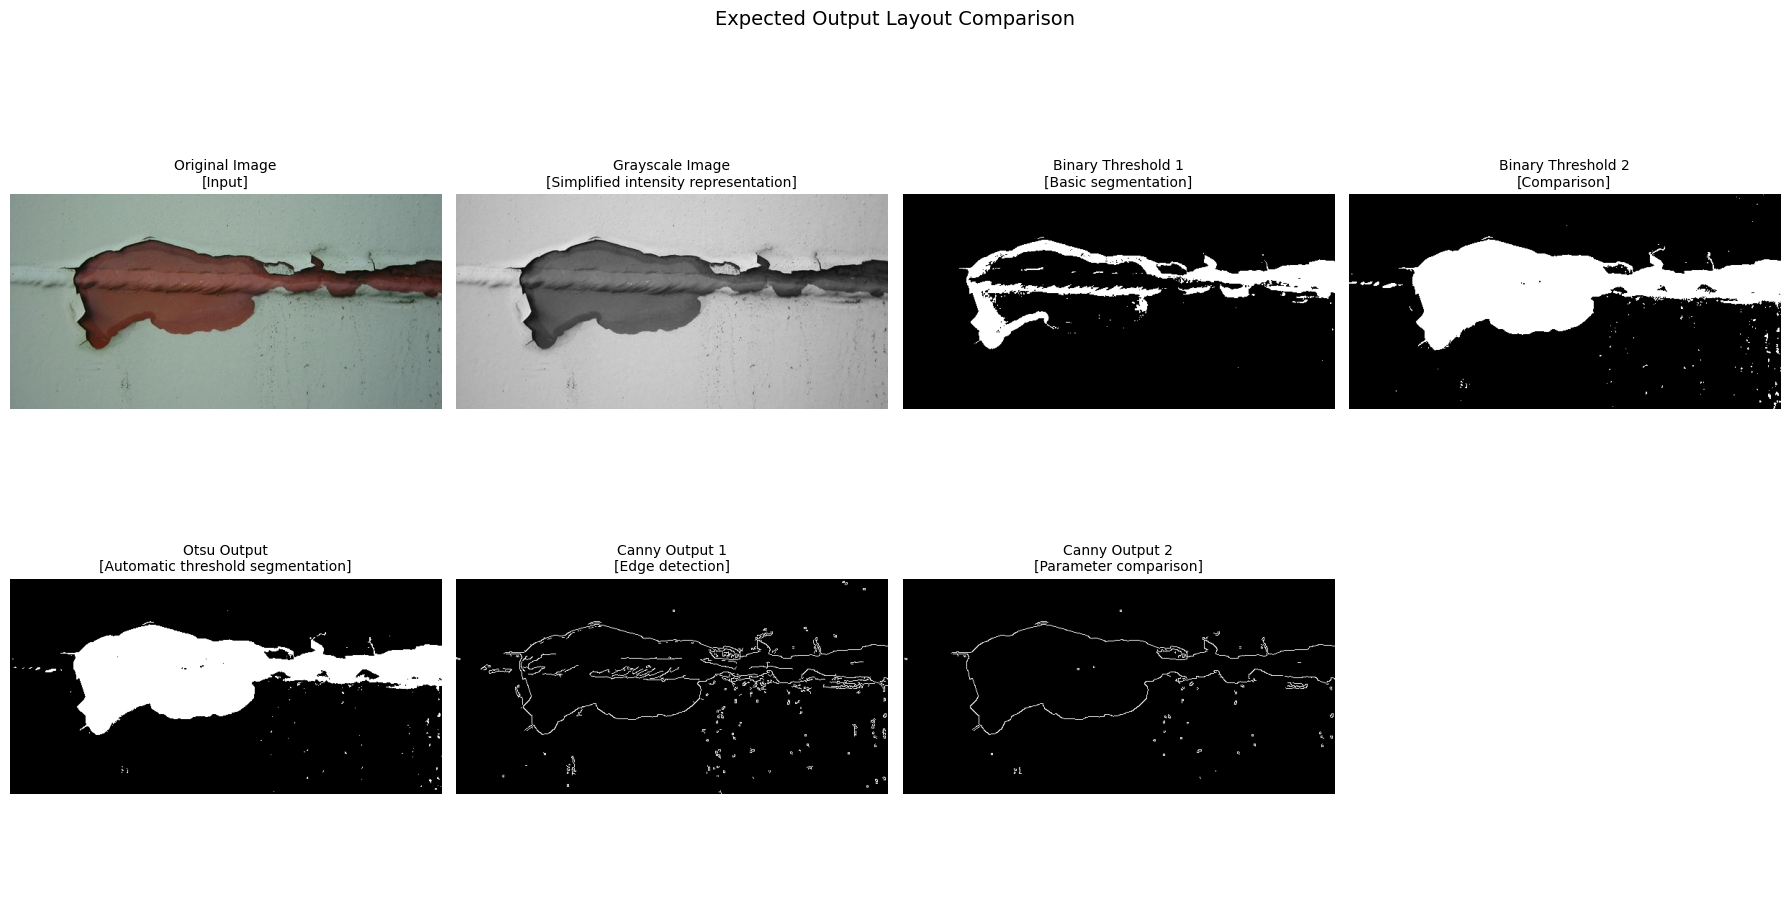

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

final_layout = [
    (img_rgb, "Original Image", "Input"),
    (img_gray, "Grayscale Image", "Simplified intensity representation"),
    (thresh_1, "Binary Threshold 1", "Basic segmentation"),
    (thresh_2, "Binary Threshold 2", "Comparison"),
    (otsu_output, "Otsu Output", "Automatic threshold segmentation"),
    (canny_output_1, "Canny Output 1", "Edge detection"),
    (canny_output_2, "Canny Output 2", "Parameter comparison"),
]

for i, ax in enumerate(axes.flat):
    if i < len(final_layout):
        image_data, title, purpose = final_layout[i]
        if len(image_data.shape) == 3:
            ax.imshow(image_data)
        else:
            ax.imshow(image_data, cmap='gray')
        ax.set_title(f"{title}\n[{purpose}]", fontsize=10)
    ax.axis('off')

plt.suptitle("Expected Output Layout Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Task 10 (Part A) & Task 7 (Part B): Selection of Most Suitable Processed Images
Based on comparative evaluation:
1. **Best Preprocessed Image (Part A):** `median_filtered` — It removes salt-and-pepper sensor noise completely while keeping defect edges sharp without blur[cite: 1, 4].
2. **Best Edge-Detected Output (Part B):** `canny_output_2 (120, 240)` — The higher threshold suppresses the brushed metallic background texture noise and isolates only the deep dent boundaries.

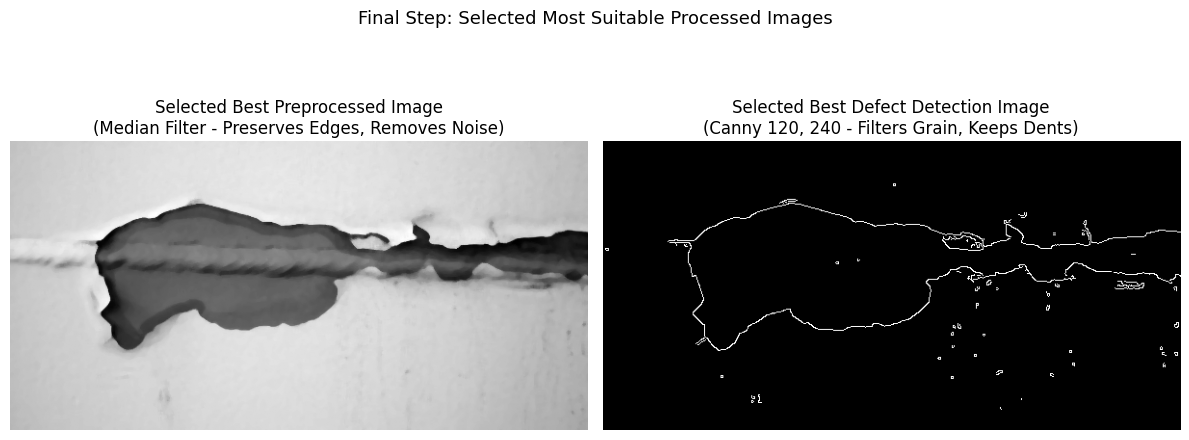

In [14]:
# Displaying the explicitly selected best images
best_preprocessed = median_filtered
best_edge_detected = canny_output_2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(best_preprocessed, cmap='gray')
axes[0].set_title("Selected Best Preprocessed Image\n(Median Filter - Preserves Edges, Removes Noise)")
axes[0].axis("off")

axes[1].imshow(best_edge_detected, cmap='gray')
axes[1].set_title("Selected Best Defect Detection Image\n(Canny 120, 240 - Filters Grain, Keeps Dents)")
axes[1].axis("off")

plt.suptitle("Final Step: Selected Most Suitable Processed Images", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()